In [1]:
# =============================================================================
# DKTC 위협 대화 분류 -- klue/roberta-base HP + Focal Loss + [턴] 토큰 + K-Fold
#
# 원본: roberta-base_hp_Focal_Loss_rev.ipynb
#
# 변경 사항 (v2):
#   [1] Focal Loss 구현 -- WeightedCE와 교체 가능, gamma OFAT 탐색
#   [2] [턴] special token 등록 -- 대화 턴 구분자를 단일 토큰으로 인식
#   [3] K-Fold 앙상블 -- OFAT best HP로 5-Fold OOF + 평균 logit 추론
#   [4] 증강 ablation 가이드 -- 전처리 파이프라인 변형 실험 안내
#
# 실험 변수 (one-factor-at-a-time):
# | 파라미터         | 탐색 범위                          |
# |-----------------|-----------------------------------|
# | learning_rate   | 1e-5, 2e-5, 5e-5                  |
# | num_epochs      | 3, 5                              |
# | weight_decay    | 0.0, 0.01, 0.1                    |
# | lr_scheduler    | linear, cosine                    |
# | warmup_ratio    | 0.0, 0.1                          |
# | label_smoothing | 0.0, 0.1                          |
# | loss_type       | weighted_ce, focal, ce            |  <- [NEW]
# | focal_gamma     | 1.0, 2.0, 3.0                     |  <- [NEW]
#
# 환경: Docker (py-gpu-env), RTX 5060 Ti 16GB, Python 3.10
# =============================================================================


In [3]:
# ============================================================================
# 00. 환경 설정 및 최적화
# ============================================================================
import sys, site, os
print("sys.executable =", sys.executable)
print("sys.prefix     =", sys.prefix)
print("site-packages  =", site.getsitepackages())

import transformers, datasets, evaluate, huggingface_hub, accelerate
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("accelerate:", accelerate.__version__)


import os, time, gc, warnings, json
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F    # Focal Loss용

# 재현성
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

from datasets import Dataset, DatasetDict
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)

# --- CPU / GPU 최적화 ---
CPU_COUNT = os.cpu_count() or 4
CPU_THREADS = max(1, CPU_COUNT // 2)

os.environ["OMP_NUM_THREADS"] = str(CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(CPU_THREADS)
os.environ["TOKENIZERS_PARALLELISM"] = "true"

torch.set_num_threads(CPU_THREADS)
try:
    torch.set_num_interop_threads(max(1, min(4, CPU_THREADS // 2)))
except RuntimeError:
    pass

USE_CUDA = torch.cuda.is_available()
DEVICE = "cuda" if USE_CUDA else "cpu"

if USE_CUDA:
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

print("=" * 70)
print(f"PyTorch              : {torch.__version__}")
print(f"CUDA available       : {USE_CUDA}")
print(f"Device               : {DEVICE}")
print(f"CPU count            : {CPU_COUNT}")
print(f"CPU threads          : {CPU_THREADS}")
if USE_CUDA:
    props = torch.cuda.get_device_properties(0)
    free_mem, total_mem = torch.cuda.memory.mem_get_info(0)

    print(f"GPU name             : {props.name}")
    print(f"GPU count            : {torch.cuda.device_count()}")
    print(f"GPU memory(total)    : {props.total_memory/ (1024**3):.2f} GB")
    print(f"GPU memory(free)     : {free_mem / (1024**3):.2f} GB")
print("=" * 70)


sys.executable = /usr/bin/python3
sys.prefix     = /usr
site-packages  = ['/usr/local/lib/python3.10/dist-packages', '/usr/lib/python3/dist-packages', '/usr/lib/python3.10/dist-packages']
transformers: 5.3.0
datasets: 4.8.2
evaluate: 0.4.6
huggingface_hub: 1.7.1
accelerate: 1.13.0
PyTorch              : 2.10.0+cu128
CUDA available       : True
Device               : cuda
CPU count            : 20
CPU threads          : 10
GPU name             : NVIDIA GeForce RTX 5060 Ti
GPU count            : 1
GPU memory(total)    : 15.93 GB
GPU memory(free)     : 13.06 GB


In [4]:
# ============================================================================
# 01. 데이터 로드 + [턴] special token 등록 + 토크나이징 (1회 실행)
# ============================================================================
MODEL_NAME = "klue/roberta-base"     # 한국어 RoBERTa (111M params)
MAX_LENGTH = 512                     # 97% 커버리지 (전처리 품질 리포트 기준)
NUM_LABELS = 5                       # 협박(0), 갈취(1), 직장내괴롭힘(2), 기타괴롭힘(3), 일반대화(4)

LABEL_NAMES = ["협박", "갈취", "직장내괴롭힘", "기타괴롭힘", "일반대화"]

# --- 전처리된 CSV 로드 ---
train_df = pd.read_csv("data/train_processed_260317_n_1000.csv")
val_df = pd.read_csv("data/val_processed_260317_n_1000.csv")

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Classes: {NUM_LABELS}")
print(f"\n학습 클래스 분포:")
print(train_df["label_name"].value_counts().to_string())
print(f"\n검증 클래스 분포:")
print(val_df["label_name"].value_counts().to_string())

# --- 토크나이저 ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# --- [NEW] [턴] special token 등록 ---
# 전처리 파이프라인의 normalize_conversation()이 대화 턴 구분자로 " [턴] "을 삽입함.
# 등록하지 않으면 [, 턴, ] 3개 subword로 분리되어 구분 신호가 희석됨.
TURN_TOKEN = "[턴]"
num_added = tokenizer.add_special_tokens({"additional_special_tokens": [TURN_TOKEN]})
print(f"\n[턴] token 등록: {num_added}개 추가 -> vocab size = {len(tokenizer)}")

# 등록 확인
test_text = "안녕하세요 [턴] 네 반갑습니다"
print(f"  토크나이징 테스트: '{test_text}'")
print(f"  -> {tokenizer.tokenize(test_text)}")

# --- Hugging Face Dataset 변환 ---
raw_datasets = DatasetDict({
    "train":      Dataset.from_pandas(train_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True)),
})

def preprocess_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH, padding=False)

tokenized_datasets = raw_datasets.map(
    preprocess_function, batched=True, batch_size=1000,
    num_proc=max(1, min(8, CPU_THREADS)),
    remove_columns=["text"], desc="Tokenizing"
)
tokenized_datasets.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if USE_CUDA else None,
    return_tensors="pt",
)

# --- Class Weight 계산 ---
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS),
    y=train_df["label"].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
if USE_CUDA:
    class_weights_tensor = class_weights_tensor.to("cuda")

print(f"\nClass weights: {dict(zip(LABEL_NAMES, class_weights.round(3)))}")
print("토크나이징 완료 -- 이후 실험에서 재사용")


Train: 3942, Val: 969, Classes: 5

학습 클래스 분포:
label_name
기타 괴롭힘 대화      808
일반 대화          800
협박 대화          778
갈취 대화          778
직장 내 괴롭힘 대화    778

검증 클래스 분포:
label_name
기타 괴롭힘 대화      202
일반 대화          200
갈취 대화          195
직장 내 괴롭힘 대화    194
협박 대화          178


Setting TOKENIZERS_PARALLELISM=false for forked processes.



[턴] token 등록: 1개 추가 -> vocab size = 32001
  토크나이징 테스트: '안녕하세요 [턴] 네 반갑습니다'
  -> ['안녕', '##하', '##세요', '[턴]', '네', '반갑', '##습', '##니다']


Tokenizing (num_proc=8): 100%|██████████| 3942/3942 [00:00<00:00, 7694.01 examples/s] 
Setting TOKENIZERS_PARALLELISM=false for forked processes.
Tokenizing (num_proc=8): 100%|██████████| 969/969 [00:00<00:00, 2902.44 examples/s]


Class weights: {'협박': np.float64(1.013), '갈취': np.float64(1.013), '직장내괴롭힘': np.float64(1.013), '기타괴롭힘': np.float64(0.976), '일반대화': np.float64(0.986)}
토크나이징 완료 -- 이후 실험에서 재사용


In [5]:
# ============================================================================
# 02. 손실 함수 + Trainer 클래스 + 실험 함수 정의
# ============================================================================
import evaluate as ev

acc_metric = ev.load("accuracy")
f1_metric  = ev.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro":    f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "f1_weighted": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }


# == [NEW] Focal Loss ======================================================
# 수식: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
#
# 구현 핵심:
#   1) CE를 weight 없이(reduction='none') 계산 -> ce_i = -log(p_t)
#   2) p_t = exp(-ce_i) 로 정답 클래스 확률 복원
#   3) focal 가중: (1 - p_t)^gamma  ->  쉬운 샘플(p_t~=1) 기여 감소
#   4) 클래스 가중(alpha)은 별도 곱셈  ->  CE의 weight 인자와 분리
#      (CE의 weight에 넣으면 p_t = exp(-w*ce) != 실제 확률 -> 수학적 오류)
# ==========================================================================

class FocalLoss(torch.nn.Module):
    """Focal Loss with optional per-class alpha weighting."""

    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        # alpha: (num_classes,) tensor -- 클래스 가중치 (e.g. compute_class_weight 결과)
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, labels):
        # (1) unweighted per-sample CE
        ce = F.cross_entropy(logits, labels, reduction="none")
        # (2) 정답 클래스 확률 p_t
        pt = torch.exp(-ce)
        # (3) focal modulation
        focal_term = (1.0 - pt) ** self.gamma * ce
        # (4) 클래스 가중치 적용 (alpha가 있을 때만)
        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, labels)
            focal_term = alpha_t * focal_term
        return focal_term.mean()


# --- WeightedTrainer: 클래스 불균형 대응 (기존 유지) ---
from torch.nn import CrossEntropyLoss

class WeightedTrainer(Trainer):
    """Weighted Cross-Entropy Trainer."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = CrossEntropyLoss(weight=class_weights_tensor)(logits, labels)
        return (loss, outputs) if return_outputs else loss


# --- [NEW] FocalLossTrainer ---
class FocalLossTrainer(Trainer):
    """Focal Loss Trainer -- gamma와 alpha(클래스 가중치)를 주입받음."""

    def __init__(self, *args, focal_gamma=2.0, focal_alpha=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal_loss_fn = FocalLoss(alpha=focal_alpha, gamma=focal_gamma)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = self.focal_loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


# --- 단일 실험 실행 함수 ---
def run_experiment(
    exp_name,
    learning_rate=2e-5,
    num_epochs=3,
    batch_size=16,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    label_smoothing_factor=0.0,
    loss_type="weighted_ce",          # <- [NEW] "weighted_ce" | "focal" | "ce"
    focal_gamma=2.0,                  # <- [NEW] focal loss gamma (loss_type="focal"일 때만 사용)
    train_dataset=None,               # <- [NEW] K-Fold용: None이면 기본 tokenized_datasets 사용
    eval_dataset=None,                # <- [NEW] K-Fold용
):
    """OFAT / K-Fold 공용 실험 함수.

    loss_type:
        "weighted_ce" -> WeightedTrainer (CrossEntropyLoss + class_weights)
        "focal"       -> FocalLossTrainer (FocalLoss + class_weights + gamma)
        "ce"          -> 기본 Trainer (label_smoothing_factor 사용 가능)

    주의: loss_type이 "weighted_ce" 또는 "focal"이면 compute_loss를 오버라이드하므로
          TrainingArguments의 label_smoothing_factor가 무시됨.
    """
    gamma_str = f", gamma={focal_gamma}" if loss_type == "focal" else ""
    print("\n" + "=" * 70)
    print(f" [{exp_name}]")
    print(f"   lr={learning_rate}, epochs={num_epochs}, batch={batch_size}, "
          f"wd={weight_decay}, warmup={warmup_ratio}, "
          f"scheduler={lr_scheduler_type}, label_smooth={label_smoothing_factor}, "
          f"loss={loss_type}{gamma_str}")
    print("=" * 70)

    # --- 데이터셋 (K-Fold에서 외부 주입 가능) ---
    _train_ds = train_dataset if train_dataset is not None else tokenized_datasets["train"]
    _eval_ds  = eval_dataset  if eval_dataset  is not None else tokenized_datasets["validation"]

    # --- 모델 새로 초기화 ---
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS
    )
    # [NEW] [턴] token embedding 확장 -- 토크나이저에 추가된 special token 반영
    model.resize_token_embeddings(len(tokenizer))

    # --- TrainingArguments ---
    supports_bf16 = USE_CUDA and torch.cuda.is_bf16_supported()

    args = TrainingArguments(
        output_dir=f"./results_dktc_{exp_name}",
        num_train_epochs=num_epochs,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        lr_scheduler_type=lr_scheduler_type,
        label_smoothing_factor=label_smoothing_factor,

        per_device_train_batch_size=batch_size if USE_CUDA else 8,
        per_device_eval_batch_size=32 if USE_CUDA else 8,

        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,

        logging_steps=50,
        report_to="none",
        disable_tqdm=False,

        dataloader_num_workers=max(1, min(8, CPU_THREADS)),
        dataloader_pin_memory=USE_CUDA,
        dataloader_persistent_workers=True,

        fp16=USE_CUDA and not supports_bf16,
        bf16=supports_bf16,
        tf32=USE_CUDA,

        optim="adamw_torch_fused" if USE_CUDA else "adamw_torch",
        seed=42,
        save_total_limit=1,
        remove_unused_columns=True,
    )

    # --- Trainer 선택 ---
    if loss_type == "focal":
        trainer = FocalLossTrainer(
            model=model, args=args,
            train_dataset=_train_ds, eval_dataset=_eval_ds,
            processing_class=tokenizer, data_collator=data_collator,
            compute_metrics=compute_metrics,
            focal_gamma=focal_gamma, focal_alpha=class_weights_tensor,
        )
    elif loss_type == "weighted_ce":
        trainer = WeightedTrainer(
            model=model, args=args,
            train_dataset=_train_ds, eval_dataset=_eval_ds,
            processing_class=tokenizer, data_collator=data_collator,
            compute_metrics=compute_metrics,
        )
    else:  # "ce" -- vanilla Trainer (label_smoothing 동작)
        trainer = Trainer(
            model=model, args=args,
            train_dataset=_train_ds, eval_dataset=_eval_ds,
            processing_class=tokenizer, data_collator=data_collator,
            compute_metrics=compute_metrics,
        )

    # NotebookProgressCallback 상태 꼬임 방지
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)

    # --- 학습 + 시간 측정 ---
    start = time.time()
    train_result = trainer.train()
    train_time = time.time() - start
    train_loss = train_result.metrics["train_loss"]

    # --- Epoch별 val 지표 추출 ---
    epoch_logs = []
    for log in trainer.state.log_history:
        if "eval_accuracy" in log:
            epoch_logs.append({
                "epoch": log.get("epoch"),
                "eval_loss": log.get("eval_loss"),
                "eval_accuracy": log.get("eval_accuracy"),
                "eval_f1_macro": log.get("eval_f1_macro"),
            })

    # --- Validation (best model) ---
    val_metrics = trainer.evaluate(_eval_ds)

    # --- Validation 상세 예측 ---
    val_result = trainer.predict(_eval_ds)
    val_logits = val_result.predictions
    val_preds = np.argmax(val_logits, axis=-1)
    val_labels = val_result.label_ids

    val_acc = acc_metric.compute(predictions=val_preds, references=val_labels)["accuracy"]
    val_f1m = f1_metric.compute(predictions=val_preds, references=val_labels, average="macro")["f1"]
    val_f1w = f1_metric.compute(predictions=val_preds, references=val_labels, average="weighted")["f1"]

    # --- 결과 dict ---
    result = {
        "exp_name": exp_name,
        "learning_rate": learning_rate,
        "num_epochs": num_epochs,
        "batch_size": batch_size,
        "weight_decay": weight_decay,
        "warmup_ratio": warmup_ratio,
        "lr_scheduler": lr_scheduler_type,
        "label_smoothing": label_smoothing_factor,
        "loss_type": loss_type,                                              # <- [NEW]
        "focal_gamma": focal_gamma if loss_type == "focal" else None,        # <- [NEW]
        "train_loss": round(train_loss, 4),
        "val_accuracy": round(val_acc, 4),
        "val_f1_macro": round(val_f1m, 4),
        "val_f1_weighted": round(val_f1w, 4),
        "train_time_sec": round(train_time, 1),
    }

    print(f"\n [{exp_name}] 완료 ({train_time:.0f}초)")
    print(f"   Val -- Acc: {result['val_accuracy']:.4f} | "
          f"F1(macro): {result['val_f1_macro']:.4f} | "
          f"F1(weighted): {result['val_f1_weighted']:.4f}")

    # --- 메모리 해제 ---
    del model, trainer
    gc.collect()
    if USE_CUDA:
        torch.cuda.empty_cache()

    return result, epoch_logs, val_preds, val_labels, val_logits


print("실험 함수 정의 완료")
print(f"  손실 함수: WeightedCE / FocalLoss(gamma) / vanilla CE")
print(f"  [턴] token: vocab size = {len(tokenizer)}")


실험 함수 정의 완료
  손실 함수: WeightedCE / FocalLoss(gamma) / vanilla CE
  [턴] token: vocab size = 32001


In [6]:
# ============================================================================
# 03. 실험 목록 정의
# ============================================================================
# Baseline: lr=2e-5, ep=3, wd=0.01, linear, warmup=0.1, weighted_ce

BASE = dict(
    learning_rate=2e-5,
    num_epochs=3,
    batch_size=16,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    label_smoothing_factor=0.0,
    loss_type="weighted_ce",
    focal_gamma=2.0,                  # focal이 아니면 무시됨
)

EXPERIMENTS = [
    # == Phase 1: OFAT (원본 실험 유지) ==
    # 1. Baseline
    {"exp_name": "baseline",    **BASE},

    # 2~3. Learning Rate
    {"exp_name": "lr_1e-5",     **{**BASE, "learning_rate": 1e-5}},
    {"exp_name": "lr_5e-5",     **{**BASE, "learning_rate": 5e-5}},

    # 4. Epoch
    {"exp_name": "epoch_5",     **{**BASE, "num_epochs": 5}},

    # 5~6. Weight Decay
    {"exp_name": "wd_0",        **{**BASE, "weight_decay": 0.0}},
    {"exp_name": "wd_0.1",      **{**BASE, "weight_decay": 0.1}},

    # 7. Cosine Scheduler
    {"exp_name": "cosine",      **{**BASE, "lr_scheduler_type": "cosine"}},

    # 8. Warmup 없음
    {"exp_name": "no_warmup",   **{**BASE, "warmup_ratio": 0.0}},

    # 9. Label Smoothing (vanilla Trainer에서만 동작)
    {"exp_name": "smooth_0.1",  **{**BASE, "label_smoothing_factor": 0.1, "loss_type": "ce"}},

    # 10. 가중치 없는 CE (vanilla Trainer)
    {"exp_name": "no_weight",   **{**BASE, "loss_type": "ce"}},

    # == Phase 2: Focal Loss OFAT ==
    # 11~13. Focal Loss gamma 탐색
    {"exp_name": "focal_g1.0",  **{**BASE, "loss_type": "focal", "focal_gamma": 1.0}},
    {"exp_name": "focal_g2.0",  **{**BASE, "loss_type": "focal", "focal_gamma": 2.0}},
    {"exp_name": "focal_g3.0",  **{**BASE, "loss_type": "focal", "focal_gamma": 3.0}},
]

print(f"실험 {len(EXPERIMENTS)}개 예정")
print("-" * 50)
for i, e in enumerate(EXPERIMENTS, 1):
    tag = ""
    if e["loss_type"] == "focal":
        tag = f" (gamma={e['focal_gamma']})"
    elif e["loss_type"] == "ce":
        tag = " (vanilla CE)"
    print(f"  {i:2d}. {e['exp_name']:16s} loss={e['loss_type']}{tag}")


실험 13개 예정
--------------------------------------------------
   1. baseline         loss=weighted_ce
   2. lr_1e-5          loss=weighted_ce
   3. lr_5e-5          loss=weighted_ce
   4. epoch_5          loss=weighted_ce
   5. wd_0             loss=weighted_ce
   6. wd_0.1           loss=weighted_ce
   7. cosine           loss=weighted_ce
   8. no_warmup        loss=weighted_ce
   9. smooth_0.1       loss=ce (vanilla CE)
  10. no_weight        loss=ce (vanilla CE)
  11. focal_g1.0       loss=focal (gamma=1.0)
  12. focal_g2.0       loss=focal (gamma=2.0)
  13. focal_g3.0       loss=focal (gamma=3.0)


In [7]:
# ============================================================================
# 실험 루프 실행
# ============================================================================
all_results = []
all_epoch_logs = {}
all_val_preds = {}
all_val_logits = {}
all_val_labels = None

for exp in EXPERIMENTS:
    result, epoch_logs, val_preds, val_labels, val_logits = run_experiment(**exp)
    all_results.append(result)
    all_epoch_logs[exp["exp_name"]] = epoch_logs
    all_val_preds[exp["exp_name"]] = val_preds
    all_val_logits[exp["exp_name"]] = val_logits
    if all_val_labels is None:
        all_val_labels = val_labels

print(f"\n{'=' * 70}")
print(f"전체 실험 완료: {len(all_results)}개")
print(f"총 소요 시간: {sum(r['train_time_sec'] for r in all_results):.0f}초 "
      f"({sum(r['train_time_sec'] for r in all_results)/60:.1f}분)")
print(f"{'=' * 70}")



 [baseline]
   lr=2e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.0, loss=weighted_ce


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1725.20it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized


 [baseline] 완료 (115초)
   Val -- Acc: 0.9185 | F1(macro): 0.9184 | F1(weighted): 0.9188

 [lr_1e-5]
   lr=1e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.0, loss=weighted_ce


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1923.00it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 [lr_1e-5] 완료 (115초)
   Val -- Acc: 0.9133 | F1(macro): 0.9132 | F1(weighted): 0.9138

 [lr_5e-5]
   lr=5e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.0, loss=weighted_ce


...


 [focal_g1.0] 완료 (111초)
   Val -- Acc: 0.9226 | F1(macro): 0.9224 | F1(weighted): 0.9230

 [focal_g2.0]
   lr=2e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.0, loss=focal, gamma=2.0


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1700.16it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 [focal_g2.0] 완료 (114초)
   Val -- Acc: 0.9257 | F1(macro): 0.9253 | F1(weighted): 0.9259

 [focal_g3.0]
   lr=2e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.0, loss=focal, gamma=3.0


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1757.54it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 [focal_g3.0] 완료 (109초)
   Val -- Acc: 0.9247 | F1(macro): 0.9243 | F1(weighted): 0.9249

전체 실험 완료: 13개
총 소요 시간: 1563초 (26.1분)


In [8]:
# ============================================================================
# 04. 전체 결과 비교
# ============================================================================
df = pd.DataFrame(all_results)

# Baseline 대비 성능 변화량
baseline_row = df[df["exp_name"] == "baseline"].iloc[0]
df["delta_val_f1_macro"] = df["val_f1_macro"] - baseline_row["val_f1_macro"]

# 정렬: val_f1_macro 내림차순
df_sorted = df.sort_values("val_f1_macro", ascending=False).reset_index(drop=True)

print("전체 실험 결과 (Val F1 Macro 내림차순)")
print("=" * 110)

display_cols = [
    "exp_name", "loss_type", "focal_gamma",
    "learning_rate", "num_epochs", "weight_decay",
    "lr_scheduler", "warmup_ratio", "label_smoothing",
    "val_accuracy", "val_f1_macro", "val_f1_weighted",
    "delta_val_f1_macro", "train_time_sec"
]
display(df_sorted[display_cols].style
    .format({
        "learning_rate": "{:.0e}",
        "val_accuracy": "{:.4f}",
        "val_f1_macro": "{:.4f}",
        "val_f1_weighted": "{:.4f}",
        "delta_val_f1_macro": "{:+.4f}",
        "focal_gamma": lambda x: f"{x:.1f}" if pd.notna(x) else "-",
    })
    .background_gradient(subset=["val_f1_macro"], cmap="RdYlGn", vmin=0.7, vmax=1.0)
    .background_gradient(subset=["delta_val_f1_macro"], cmap="RdYlGn", vmin=-0.05, vmax=0.05)
)


전체 실험 결과 (Val F1 Macro 내림차순)


,exp_name,loss_type,focal_gamma,learning_rate,num_epochs,weight_decay,lr_scheduler,warmup_ratio,label_smoothing,val_accuracy,val_f1_macro,val_f1_weighted,delta_val_f1_macro,train_time_sec
0,wd_0.1,weighted_ce,-,2e-05,3,0.100000,linear,0.100000,0.000000,0.9278,0.9275,0.9280,+0.0091,119.400000
1,no_weight,ce,-,2e-05,3,0.010000,linear,0.100000,0.000000,0.9267,0.9265,0.9270,+0.0081,116.800000
2,focal_g2.0,focal,2.0,2e-05,3,0.010000,linear,0.100000,0.000000,0.9257,0.9253,0.9259,+0.0069,113.800000
3,focal_g3.0,focal,3.0,2e-05,3,0.010000,linear,0.100000,0.000000,0.9247,0.9243,0.9249,+0.0059,109.200000
4,wd_0,weighted_ce,-,2e-05,3,0.000000,linear,0.100000,0.000000,0.9236,0.9234,0.9239,+0.0050,114.800000
5,cosine,weighted_ce,-,2e-05,3,0.010000,cosine,0.100000,0.000000,0.9236,0.9233,0.9238,+0.0049,117.900000
6,focal_g1.0,focal,1.0,2e-05,3,0.010000,linear,0.100000,0.000000,0.9226,0.9224,0.9230,+0.0040,110.500000
7,smooth_0.1,ce,-,2e-05,3,0.010000,linear,0.100000,0.100000,0.9226,0.9223,0.9228,+0.0039,114.700000
8,epoch_5,weighted_ce,-,2e-05,5,0.010000,linear,0.100000,0.000000,0.9216,0.9214,0.9218,+0.0030,190.400000
9,baseline,weighted_ce,-,2e-05,3,0.010000,linear,0.100000,0.000000,0.9185,0.9184,0.9188,+0.0000,115.400000


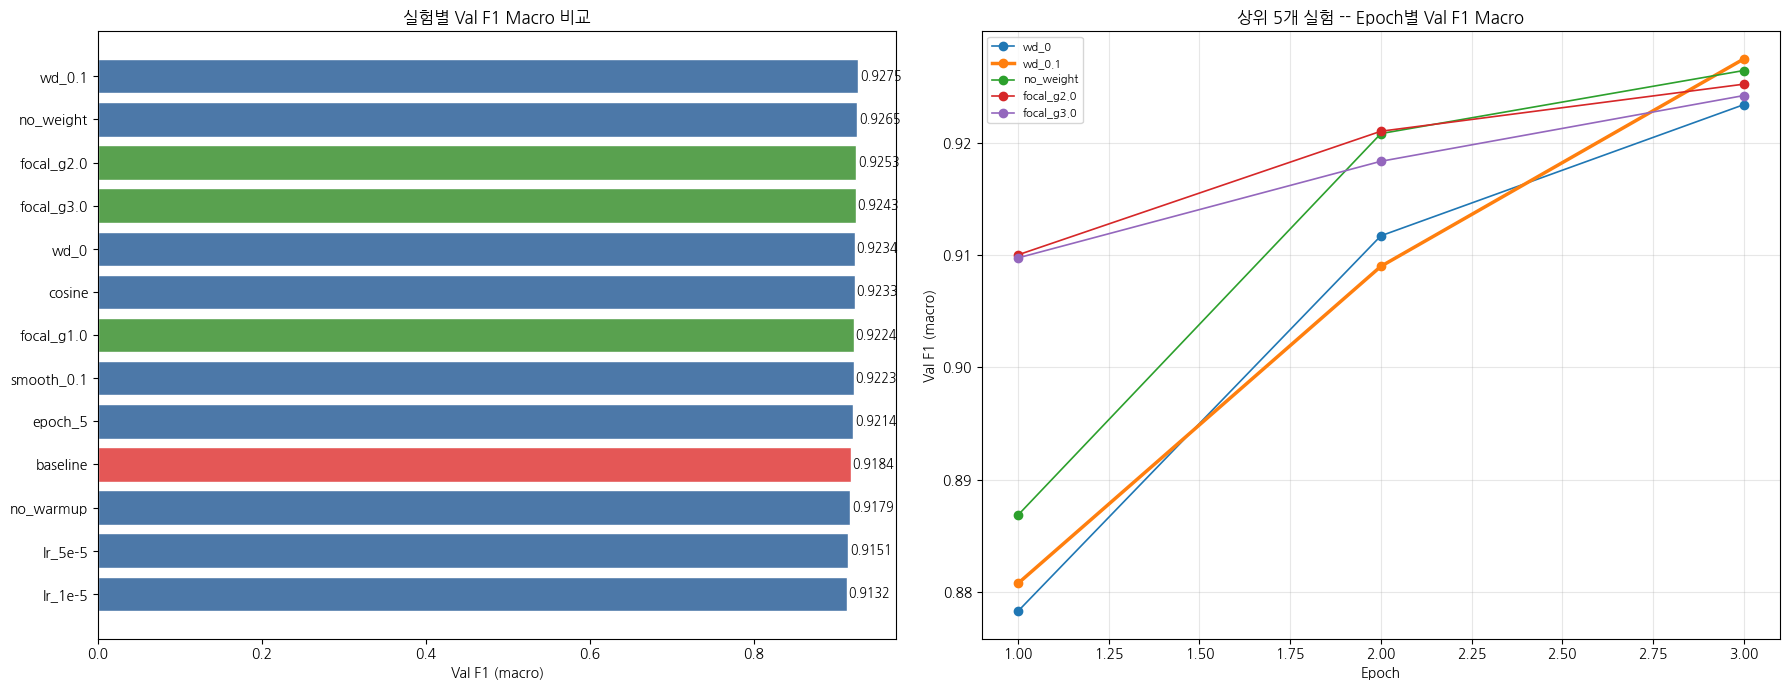

  -> 저장: dktc_hp_focal_v2_experiment_chart.png


In [9]:
# ============================================================================
# 05. 시각화
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 한글 폰트 ---
font_candidates = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
]
font_path = None
for fc in font_candidates:
    if os.path.exists(fc):
        font_path = fc
        break
if font_path:
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# --- (a) 실험별 Val F1 Macro 비교 바 차트 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
sorted_results = sorted(all_results, key=lambda x: x["val_f1_macro"], reverse=True)
names = [r["exp_name"] for r in sorted_results]
f1s = [r["val_f1_macro"] for r in sorted_results]

# 색상: baseline=빨강, focal=초록, 나머지=파랑
def bar_color(name):
    if name == "baseline": return "#E45756"
    if name.startswith("focal"): return "#59A14F"
    return "#4C78A8"
bar_colors = [bar_color(n) for n in names]

ax.barh(names, f1s, color=bar_colors, edgecolor="white")
ax.set_xlabel("Val F1 (macro)")
ax.set_title("실험별 Val F1 Macro 비교")
ax.invert_yaxis()
for i, v in enumerate(f1s):
    ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

# --- (b) Epoch별 학습 곡선 (상위 5개) ---
ax = axes[1]
top5 = [r["exp_name"] for r in sorted_results[:5]]
for exp_name, logs in all_epoch_logs.items():
    if not logs or exp_name not in top5:
        continue
    epochs = [l["epoch"] for l in logs]
    f1_vals = [l["eval_f1_macro"] for l in logs]
    lw = 2.5 if exp_name == sorted_results[0]["exp_name"] else 1.2
    ax.plot(epochs, f1_vals, marker="o", label=exp_name, linewidth=lw)

ax.set_xlabel("Epoch")
ax.set_ylabel("Val F1 (macro)")
ax.set_title("상위 5개 실험 -- Epoch별 Val F1 Macro")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dktc_hp_focal_experiment_v2_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("  -> 저장: dktc_hp_focal_v2_experiment_chart.png")


In [10]:
# ============================================================================
# 06. Best 모델 상세 분석 (classification_report)
# ============================================================================
best_name = df_sorted.iloc[0]["exp_name"]
best_preds = all_val_preds[best_name]
best_logits = all_val_logits[best_name]
best_f1 = df_sorted.iloc[0]["val_f1_macro"]

print(f"Best 모델: {best_name} (Val F1 Macro: {best_f1:.4f})")
print("=" * 70)
print(classification_report(
    all_val_labels,
    best_preds,
    target_names=LABEL_NAMES,
    digits=4
))

# 오분류 패턴 분석
from collections import Counter
wrong_mask = best_preds != all_val_labels
if wrong_mask.sum() > 0:
    print(f"\n오분류 건수: {wrong_mask.sum()} / {len(all_val_labels)} ({wrong_mask.mean()*100:.1f}%)")
    print("\n오분류 패턴 (실제->예측):")
    wrong_pairs = list(zip(all_val_labels[wrong_mask], best_preds[wrong_mask]))
    for (true_cls, pred_cls), cnt in Counter(wrong_pairs).most_common(10):
        print(f"  {LABEL_NAMES[true_cls]:10s} -> {LABEL_NAMES[pred_cls]:10s}: {cnt}건")


Best 모델: wd_0.1 (Val F1 Macro: 0.9275)
              precision    recall  f1-score   support

          협박     0.9240    0.8876    0.9054       178
          갈취     0.8627    0.9026    0.8822       195
      직장내괴롭힘     0.9637    0.9588    0.9612       194
       기타괴롭힘     0.8966    0.9010    0.8988       202
        일반대화     0.9949    0.9850    0.9899       200

    accuracy                         0.9278       969
   macro avg     0.9284    0.9270    0.9275       969
weighted avg     0.9285    0.9278    0.9280       969


오분류 건수: 70 / 969 (7.2%)

오분류 패턴 (실제->예측):
  기타괴롭힘      -> 갈취        : 14건
  협박         -> 갈취        : 11건
  갈취         -> 기타괴롭힘     : 8건
  갈취         -> 협박        : 8건
  협박         -> 기타괴롭힘     : 8건
  기타괴롭힘      -> 협박        : 4건
  직장내괴롭힘     -> 기타괴롭힘     : 4건
  갈취         -> 직장내괴롭힘    : 3건
  직장내괴롭힘     -> 갈취        : 3건
  일반대화       -> 직장내괴롭힘    : 2건


In [11]:
# ============================================================================
# 07. 결과 저장
# ============================================================================
df_final = pd.DataFrame(all_results)
df_final.to_csv("dktc_hp_focal_v2_experiment_results.csv", index=False)

with open("dktc_hp_focal_v2_epoch_logs.json", "w") as f:
    json.dump(all_epoch_logs, f, indent=2)

print("dktc_hp_focal_v2_experiment_results.csv 저장 완료")
print("dktc_hp_focal_v2_epoch_logs.json 저장 완료")
print(f"\n총 실험 수: {len(all_results)}")
print(f"총 소요 시간: {df_final['train_time_sec'].sum():.0f}초 ({df_final['train_time_sec'].sum()/60:.1f}분)")
print(f"\nBest: {best_name} -> Val F1 Macro: {best_f1:.4f}")


dktc_hp_focal_v2_experiment_results.csv 저장 완료
dktc_hp_focal_v2_epoch_logs.json 저장 완료

총 실험 수: 13
총 소요 시간: 1563초 (26.1분)

Best: wd_0.1 -> Val F1 Macro: 0.9275



 오분류 원문 + top-2 확률/마진 분석
Best 모델: wd_0.1 (Val F1 Macro: 0.9275)
검증 샘플 수: 969
텍스트 컬럼: text

[오분류 전체] 70건 / 969건 (7.2%)

오분류 패턴 (실제→예측):
error_pair
기타괴롭힘 → 갈취        14
협박 → 갈취           11
갈취 → 기타괴롭힘         8
협박 → 기타괴롭힘         8
갈취 → 협박            8
직장내괴롭힘 → 기타괴롭힘     4
기타괴롭힘 → 협박         4
직장내괴롭힘 → 갈취        3
갈취 → 직장내괴롭힘        3
일반대화 → 직장내괴롭힘      2
일반대화 → 기타괴롭힘       1
직장내괴롭힘 → 협박        1
협박 → 직장내괴롭힘        1
기타괴롭힘 → 일반대화       1
기타괴롭힘 → 직장내괴롭힘     1

저장 완료: dktc_all_misclassified_with_top2.csv

저장 완료: dktc_misclassification_pair_summary.csv
  [기타괴롭힘 → 갈취]  14건 (mean margin=0.794) → misclassified_pairs_with_top2/기타괴롭힘_to_갈취_csv
  [협박 → 갈취]  11건 (mean margin=0.919) → misclassified_pairs_with_top2/협박_to_갈취_csv
  [갈취 → 협박]   8건 (mean margin=0.463) → misclassified_pairs_with_top2/갈취_to_협박_csv
  [협박 → 기타괴롭힘]   8건 (mean margin=0.973) → misclassified_pairs_with_top2/협박_to_기타괴롭힘_csv
  [갈취 → 기타괴롭힘]   8건 (mean margin=0.885) → misclassified_pairs_with_top2/갈취_to_기타괴롭힘_csv
  [기타괴롭힘 → 협박]   

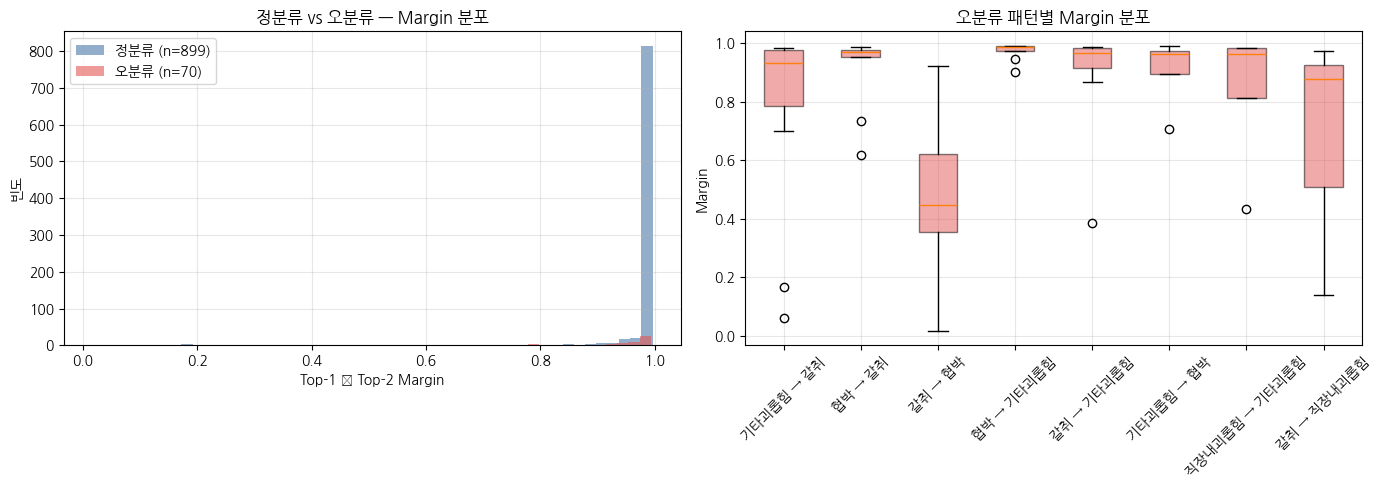

  → 저장: dktc_misclassification_margin_analysis.png

완료


In [12]:
# ============================================================================
# 08. 오분류 원문 + top-2 확률/마진 분석 (HP 튜닝 단일 모델 기준)
#
# 사용 변수:
#   best_preds, best_logits, all_val_labels, val_df, LABEL_NAMES, df_sorted
# ============================================================================

import os, re
import numpy as np
import pandas as pd
from collections import Counter

print("\n" + "=" * 70)
print(" 오분류 원문 + top-2 확률/마진 분석")
print("=" * 70)

# ---------------------------------------------------------------------------
# 0) 유틸
# ---------------------------------------------------------------------------
def softmax_np(x):
    """Numerically stable softmax"""
    x = np.asarray(x, dtype=np.float64)
    x_max = np.max(x, axis=1, keepdims=True)
    e = np.exp(x - x_max)
    return e / np.sum(e, axis=1, keepdims=True)

def top2_from_logits(logits, label_names):
    """logits → top-1/top-2 레이블, 확률, 마진"""
    probs = softmax_np(logits)
    order = np.argsort(-probs, axis=1)[:, :2]
    top1_id  = order[:, 0]
    top2_id  = order[:, 1]
    top1_prob = probs[np.arange(len(probs)), top1_id]
    top2_prob = probs[np.arange(len(probs)), top2_id]
    margin    = top1_prob - top2_prob
    return {
        "top1_id":    top1_id,
        "top1_label": np.array([label_names[int(i)] for i in top1_id], dtype=object),
        "top1_prob":  top1_prob,
        "top2_id":    top2_id,
        "top2_label": np.array([label_names[int(i)] for i in top2_id], dtype=object),
        "top2_prob":  top2_prob,
        "margin":     margin,
        "probs":      probs,
    }

def safe_filename(s: str) -> str:
    s = re.sub(r"[^\w가-힣\- ]+", "_", s)
    return s.replace(" ", "_")

# ---------------------------------------------------------------------------
# 1) 필수 변수 확인
# ---------------------------------------------------------------------------
assert "best_preds"     in dir(), "best_preds가 없습니다. 셀 06을 먼저 실행하세요."
assert "best_logits"    in dir(), "best_logits가 없습니다. 셀 06을 먼저 실행하세요."
assert "all_val_labels" in dir(), "all_val_labels가 없습니다."
assert "val_df"         in dir(), "val_df가 없습니다."
assert "LABEL_NAMES"    in dir(), "LABEL_NAMES가 없습니다."
assert "df_sorted"      in dir(), "df_sorted가 없습니다."

best_name = df_sorted.iloc[0]["exp_name"]
best_f1   = df_sorted.iloc[0]["val_f1_macro"]

print(f"Best 모델: {best_name} (Val F1 Macro: {best_f1:.4f})")
print(f"검증 샘플 수: {len(val_df)}")

# ---------------------------------------------------------------------------
# 2) 텍스트 컬럼 자동 탐색
# ---------------------------------------------------------------------------
text_col = None
for c in ["text", "sentence", "document", "utterance", "content"]:
    if c in val_df.columns:
        text_col = c
        break
if text_col is None:
    raise RuntimeError(f"텍스트 컬럼을 찾지 못했습니다. 실제 컬럼: {list(val_df.columns)}")

print(f"텍스트 컬럼: {text_col}")

# ---------------------------------------------------------------------------
# 3) top-2 확률/마진 계산
# ---------------------------------------------------------------------------
y_true = np.asarray(all_val_labels).astype(int)
y_pred = np.asarray(best_preds).astype(int)

t2 = top2_from_logits(best_logits, LABEL_NAMES)

# ---------------------------------------------------------------------------
# 4) 결과 테이블 생성
# ---------------------------------------------------------------------------
df_analysis = val_df.copy().reset_index(drop=False).rename(columns={"index": "orig_index"})

df_analysis["true_label_id"]  = y_true
df_analysis["pred_label_id"]  = y_pred
df_analysis["true_label"]     = df_analysis["true_label_id"].map(lambda x: LABEL_NAMES[int(x)])
df_analysis["pred_label"]     = df_analysis["pred_label_id"].map(lambda x: LABEL_NAMES[int(x)])
df_analysis["is_wrong"]       = y_true != y_pred
df_analysis["error_pair"]     = df_analysis["true_label"] + " → " + df_analysis["pred_label"]

# top-2 정보 추가
df_analysis["top1_label"] = t2["top1_label"]
df_analysis["top1_prob"]  = t2["top1_prob"]
df_analysis["top2_label"] = t2["top2_label"]
df_analysis["top2_prob"]  = t2["top2_prob"]
df_analysis["margin"]     = t2["margin"]

# 클래스별 확률 열
for i, name in enumerate(LABEL_NAMES):
    df_analysis[f"prob_{name}"] = t2["probs"][:, i]

# ---------------------------------------------------------------------------
# 5) 오분류 전체 추출
# ---------------------------------------------------------------------------
errors_df = df_analysis[df_analysis["is_wrong"]].copy()

print(f"\n[오분류 전체] {len(errors_df)}건 / {len(df_analysis)}건 "
      f"({len(errors_df)/len(df_analysis)*100:.1f}%)")
print("\n오분류 패턴 (실제→예측):")
print(errors_df["error_pair"].value_counts().to_string())

errors_df.to_csv(
    "dktc_all_misclassified_with_top2.csv",
    index=False,
    encoding="utf-8-sig"
)
print("\n저장 완료: dktc_all_misclassified_with_top2.csv")

# ---------------------------------------------------------------------------
# 6) 오분류 패턴별 요약 + 개별 CSV 저장
# ---------------------------------------------------------------------------
out_dir = "misclassified_pairs_with_top2"
os.makedirs(out_dir, exist_ok=True)

pair_summary = (
    errors_df.groupby(["true_label", "pred_label"])
    .agg(
        count=("is_wrong", "size"),
        mean_margin=("margin", "mean"),
        min_margin=("margin", "min"),
        max_margin=("margin", "max"),
    )
    .reset_index()
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
pair_summary["error_pair"] = pair_summary["true_label"] + " → " + pair_summary["pred_label"]
pair_summary.to_csv("dktc_misclassification_pair_summary.csv", index=False, encoding="utf-8-sig")
print("\n저장 완료: dktc_misclassification_pair_summary.csv")

for _, row in pair_summary.iterrows():
    true_name = row["true_label"]
    pred_name = row["pred_label"]
    cnt       = int(row["count"])

    pair_df = errors_df[
        (errors_df["true_label"] == true_name) &
        (errors_df["pred_label"] == pred_name)
    ].copy().sort_values("margin", ascending=True).reset_index(drop=True)

    save_name = safe_filename(f"{true_name}_to_{pred_name}.csv")
    save_path = os.path.join(out_dir, save_name)
    pair_df.to_csv(save_path, index=False, encoding="utf-8-sig")
    print(f"  [{true_name} → {pred_name}] {cnt:3d}건 (mean margin={row['mean_margin']:.3f}) → {save_path}")

# ---------------------------------------------------------------------------
# 7) 애매한 오분류 top-30 / 확신 오분류 top-30
# ---------------------------------------------------------------------------
ambiguous_top = errors_df.sort_values("margin", ascending=True).head(30).copy()
confident_wrong_top = errors_df.sort_values("margin", ascending=False).head(30).copy()

ambiguous_top.to_csv(
    "dktc_misclassified_most_ambiguous_top30.csv",
    index=False, encoding="utf-8-sig"
)
confident_wrong_top.to_csv(
    "dktc_misclassified_most_confident_top30.csv",
    index=False, encoding="utf-8-sig"
)
print("\n저장 완료: dktc_misclassified_most_ambiguous_top30.csv")
print("저장 완료: dktc_misclassified_most_confident_top30.csv")

# ---------------------------------------------------------------------------
# 8) 주요 오분류 패턴별 원문 샘플 출력
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print(" 주요 오분류 패턴별 원문 샘플 (상위 5패턴, 각 3건)")
print("=" * 70)

for _, row in pair_summary.head(5).iterrows():
    true_name = row["true_label"]
    pred_name = row["pred_label"]
    cnt       = int(row["count"])

    pair_df = errors_df[
        (errors_df["true_label"] == true_name) &
        (errors_df["pred_label"] == pred_name)
    ].sort_values("margin", ascending=True)   # 가장 애매한 건부터

    print(f"\n--- [{true_name} → {pred_name}] ({cnt}건, mean margin={row['mean_margin']:.3f}) ---")
    for i, (_, sample) in enumerate(pair_df.head(3).iterrows()):
        text_preview = str(sample[text_col])[:120].replace("\n", " ")
        print(f"  [{i+1}] margin={sample['margin']:.3f} | "
              f"top1={sample['top1_label']}({sample['top1_prob']:.2%}) "
              f"top2={sample['top2_label']}({sample['top2_prob']:.2%})")
        print(f"      \"{text_preview}...\"")

# ---------------------------------------------------------------------------
# 9) margin 분포 시각화
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) 정분류 vs 오분류 margin 분포
ax = axes[0]
correct_margins = df_analysis[~df_analysis["is_wrong"]]["margin"]
wrong_margins   = errors_df["margin"]

ax.hist(correct_margins, bins=50, alpha=0.6, label=f"정분류 (n={len(correct_margins)})", color="#4C78A8")
ax.hist(wrong_margins,   bins=50, alpha=0.6, label=f"오분류 (n={len(wrong_margins)})",   color="#E45756")
ax.set_xlabel("Top-1 − Top-2 Margin")
ax.set_ylabel("빈도")
ax.set_title("정분류 vs 오분류 — Margin 분포")
ax.legend()
ax.grid(True, alpha=0.3)

# (b) 오분류 패턴별 margin boxplot (상위 8개)
ax = axes[1]
top_pairs = pair_summary.head(8)["error_pair"].tolist()
box_data = [errors_df[errors_df["error_pair"] == p]["margin"].values for p in top_pairs]

bp = ax.boxplot(box_data, labels=top_pairs, vert=True, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#E45756")
    patch.set_alpha(0.5)
ax.set_ylabel("Margin")
ax.set_title("오분류 패턴별 Margin 분포")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dktc_misclassification_margin_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → 저장: dktc_misclassification_margin_analysis.png")

print("\n완료")

In [13]:
# ============================================================================
# 09. [NEW] K-Fold 앙상블 -- OFAT best HP로 5-Fold OOF
#
# 목적: 단일 split의 분산을 줄이고, Kaggle 제출 시 fold별 logit 평균으로
#       더 안정적인 예측을 얻기 위함.
#
# 주의: 현재 train_processed CSV에는 증강 데이터가 포함되어 있음.
#       엄밀한 K-Fold를 위해서는 전처리 파이프라인에서 증강 전 원본만
#       저장한 CSV를 사용하는 것이 이상적. 여기서는 train+val을 합쳐
#       K-Fold를 수행하되, 이 한계를 인지하고 사용할 것.
# ============================================================================
from sklearn.model_selection import StratifiedKFold

print("=" * 70)
print(" K-Fold 앙상블 (OFAT Best HP 기반)")
print("=" * 70)

# --- OFAT best HP 추출 ---
best_row = df_sorted.iloc[0]
KFOLD_HP = {
    "learning_rate":        best_row["learning_rate"],
    "num_epochs":           int(best_row["num_epochs"]),
    "batch_size":           16,
    "weight_decay":         best_row["weight_decay"],
    "warmup_ratio":         best_row["warmup_ratio"],
    "lr_scheduler_type":    best_row["lr_scheduler"],
    "label_smoothing_factor": best_row["label_smoothing"],
    "loss_type":            best_row["loss_type"],
    "focal_gamma":          best_row["focal_gamma"] if pd.notna(best_row.get("focal_gamma")) else 2.0,
}

print(f"Best 실험: {best_row['exp_name']} (Val F1 Macro: {best_row['val_f1_macro']:.4f})")
print(f"적용 HP: {json.dumps({k: str(v) for k, v in KFOLD_HP.items()}, indent=2)}")

# --- 전체 데이터 합치기 ---
full_df = pd.concat([train_df, val_df], ignore_index=True)
print(f"\n전체 데이터: {len(full_df)}개")
print(f"클래스 분포:\n{full_df['label_name'].value_counts().to_string()}")

# --- 전체 데이터 토크나이징 (1회) ---
full_raw = Dataset.from_pandas(
    full_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True)
)
full_tokenized = full_raw.map(
    preprocess_function, batched=True, batch_size=1000,
    num_proc=max(1, min(8, CPU_THREADS)),
    remove_columns=["text"], desc="K-Fold Tokenizing"
)
full_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# --- K-Fold 실행 ---
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_logits = np.zeros((len(full_df), NUM_LABELS))  # Out-of-Fold logits
fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(full_df, full_df["label"])):
    fold_name = f"kfold_{fold_idx+1}of{N_FOLDS}"

    fold_train_ds = full_tokenized.select(train_idx.tolist())
    fold_val_ds   = full_tokenized.select(val_idx.tolist())

    result, _, val_preds, val_labels, val_logits = run_experiment(
        exp_name=fold_name,
        train_dataset=fold_train_ds,
        eval_dataset=fold_val_ds,
        **KFOLD_HP,
    )
    fold_results.append(result)

    # OOF logits 저장
    oof_logits[val_idx] = val_logits

# --- OOF 전체 평가 ---
oof_preds = np.argmax(oof_logits, axis=-1)
oof_labels = full_df["label"].values

oof_acc = acc_metric.compute(predictions=oof_preds, references=oof_labels)["accuracy"]
oof_f1m = f1_metric.compute(predictions=oof_preds, references=oof_labels, average="macro")["f1"]
oof_f1w = f1_metric.compute(predictions=oof_preds, references=oof_labels, average="weighted")["f1"]

print("\n" + "=" * 70)
print(f" K-Fold OOF 결과 ({N_FOLDS}-Fold)")
print("=" * 70)
print(f"  OOF Accuracy:    {oof_acc:.4f}")
print(f"  OOF F1 (macro):  {oof_f1m:.4f}")
print(f"  OOF F1 (weighted): {oof_f1w:.4f}")
print(f"\n  개별 Fold Val F1 Macro:")
for r in fold_results:
    print(f"    {r['exp_name']}: {r['val_f1_macro']:.4f}")
print(f"  Fold 평균: {np.mean([r['val_f1_macro'] for r in fold_results]):.4f}")
print(f"  Fold 표준편차: {np.std([r['val_f1_macro'] for r in fold_results]):.4f}")

print("\n" + classification_report(oof_labels, oof_preds, target_names=LABEL_NAMES, digits=4))

# --- OOF 결과 저장 ---
oof_df = pd.DataFrame(fold_results)
oof_df.to_csv("dktc_kfold_results.csv", index=False)
np.save("dktc_kfold_oof_logits.npy", oof_logits)
print("저장 완료: dktc_kfold_results.csv, dktc_kfold_oof_logits.npy")


Setting TOKENIZERS_PARALLELISM=false for forked processes.


 K-Fold 앙상블 (OFAT Best HP 기반)
Best 실험: wd_0.1 (Val F1 Macro: 0.9275)
적용 HP: {
  "learning_rate": "2e-05",
  "num_epochs": "3",
  "batch_size": "16",
  "weight_decay": "0.1",
  "warmup_ratio": "0.1",
  "lr_scheduler_type": "linear",
  "label_smoothing_factor": "0.0",
  "loss_type": "weighted_ce",
  "focal_gamma": "2.0"
}

전체 데이터: 4911개
클래스 분포:
label_name
기타 괴롭힘 대화      1010
일반 대화          1000
갈취 대화           973
직장 내 괴롭힘 대화     972
협박 대화           956


K-Fold Tokenizing (num_proc=8): 100%|██████████| 4911/4911 [00:00<00:00, 8454.47 examples/s] 



 [kfold_1of5]
   lr=2e-05, epochs=3, batch=16, wd=0.1, warmup=0.1, scheduler=linear, label_smooth=0.0, loss=weighted_ce


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1838.98it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be

...


 [kfold_3of5] 완료 (106초)
   Val -- Acc: 0.9501 | F1(macro): 0.9500 | F1(weighted): 0.9500

 [kfold_4of5]
   lr=2e-05, epochs=3, batch=16, wd=0.1, warmup=0.1, scheduler=linear, label_smooth=0.0, loss=weighted_ce


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1970.77it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 [kfold_4of5] 완료 (110초)
   Val -- Acc: 0.9206 | F1(macro): 0.9208 | F1(weighted): 0.9210

 [kfold_5of5]
   lr=2e-05, epochs=3, batch=16, wd=0.1, warmup=0.1, scheduler=linear, label_smooth=0.0, loss=weighted_ce


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1658.62it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 [kfold_5of5] 완료 (106초)
   Val -- Acc: 0.9236 | F1(macro): 0.9237 | F1(weighted): 0.9238

 K-Fold OOF 결과 (5-Fold)
  OOF Accuracy:    0.9287
  OOF F1 (macro):  0.9287
  OOF F1 (weighted): 0.9288

  개별 Fold Val F1 Macro:
    kfold_1of5: 0.9263
    kfold_2of5: 0.9227
    kfold_3of5: 0.9500
    kfold_4of5: 0.9208
    kfold_5of5: 0.9237
  Fold 평균: 0.9287
  Fold 표준편차: 0.0108

              precision    recall  f1-score   support

          협박     0.9014    0.9184    0.9098       956
          갈취     0.8961    0.9044    0.9003       973
      직장내괴롭힘     0.9587    0.9558    0.9572       972
       기타괴롭힘     0.8934    0.8792    0.8862      1010
        일반대화     0.9940    0.9860    0.9900      1000

    accuracy                         0.9287      4911
   macro avg     0.9287    0.9288    0.9287      4911
weighted avg     0.9289    0.9287    0.9288      4911

저장 완료: dktc_kfold_results.csv, dktc_kfold_oof_logits.npy


## 10. [참고] 증강 ablation 실험 가이드

턴 셔플(`augment_turn_shuffle`)이 위협 대화의 시간 구조를 깨뜨릴 가능성이 있으므로,
증강 전략별 성능 차이를 확인하는 것이 권장됨.

### 실험 방법

`merge_preprocessing_pipeline.ipynb`의 `augment_data()` 함수에서 `augmenters` 리스트를 변경:

| 실험명 | augmenters 설정 | 출력 파일 |
|--------|----------------|-----------|
| aug_all | `[turn_shuffle, random_deletion, turn_drop]` (현재) | `train_processed_260317_n_1000.csv` |
| aug_no_shuffle | `[random_deletion, turn_drop]` | `train_processed_260317_n_1000_no_shuffle.csv` |
| aug_deletion_only | `[random_deletion]` | `train_processed_260317_n_1000_del_only.csv` |
| aug_none | 증강 비활성화 (`target_per_class=0` 또는 `augment_data` 호출 제거) | `train_processed_260317_n_1000_noaug.csv` |

각 CSV를 본 노트북의 Cell 01에서 `train_df = pd.read_csv(...)` 경로만 바꿔서 동일 baseline HP로 실행하여 F1 비교.

### 핵심 가설

> "턴 셔플 제거 시 F1이 올라간다면, 위협 대화의 순서 구조가 분류에 핵심적이며 셔플이 해를 끼치고 있었음."
